# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [27]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.20.0
GPU: True
NumPy: 2.0.2


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


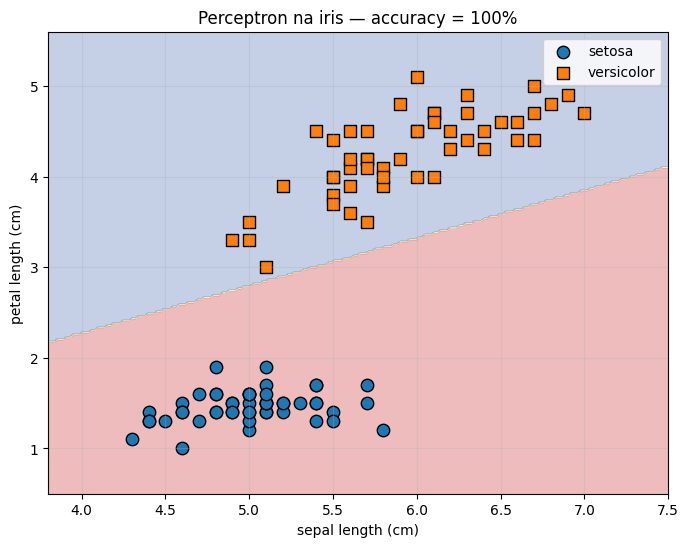


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [28]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Test Accuracy (Trouser vs Sneaker): 99.95%


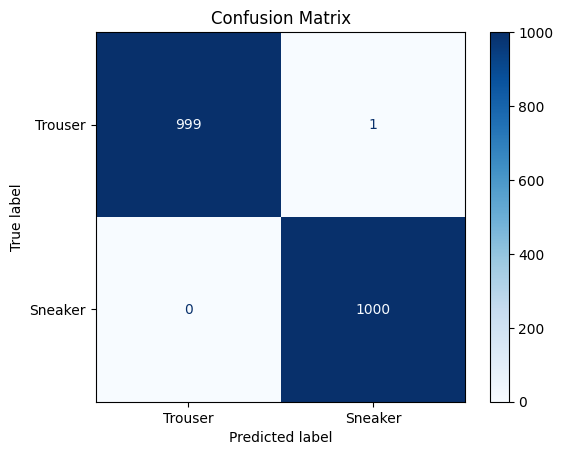

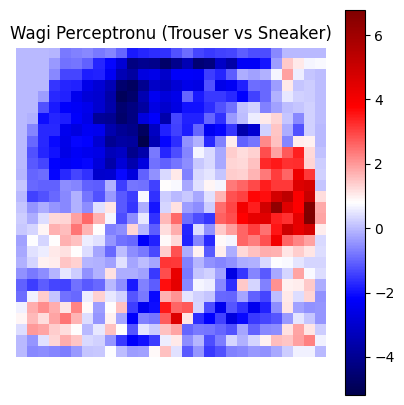

Liczba błędów: 1


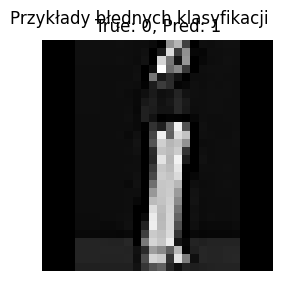

In [29]:
from datasets import load_dataset
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

ds = load_dataset("zalando-datasets/fashion_mnist")

def prepare_data(split, class_a=1, class_b=7):
    data = ds[split]
    labels = np.array(data["label"])
    mask = (labels == class_a) | (labels == class_b)

    imgs = np.array([np.array(img) for img in np.array(data["image"])[mask]])
    X = imgs.reshape(len(imgs), -1) / 255.0
    y = (labels[mask] == class_b).astype(int)
    return X, y, imgs

X_train, y_train, _ = prepare_data("train")
X_test, y_test, imgs_test = prepare_data("test")

clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy (Trouser vs Sneaker): {acc:.2%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Trouser", "Sneaker"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(5, 5))
weights_img = clf.coef_.reshape(28, 28)
plt.imshow(weights_img, cmap="seismic")
plt.colorbar()
plt.title("Wagi Perceptronu (Trouser vs Sneaker)")
plt.axis("off")
plt.show()

errors_idx = np.where(y_pred != y_test)[0]
print(f"Liczba błędów: {len(errors_idx)}")

if len(errors_idx) > 0:
    n_show = min(5, len(errors_idx))
    fig, axes = plt.subplots(1, n_show, figsize=(15, 3), squeeze=False)
    for i in range(n_show):
        idx = errors_idx[i]
        axes[0, i].imshow(imgs_test[idx], cmap="gray")
        axes[0, i].set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
        axes[0, i].axis("off")
    plt.suptitle("Przykłady błędnych klasyfikacji")
    plt.show()

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


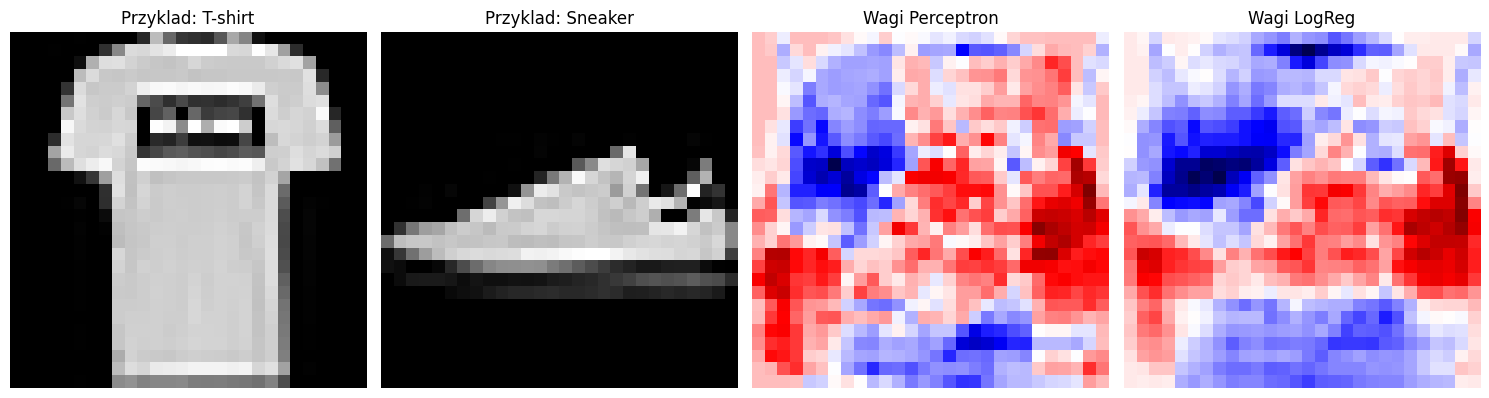


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [30]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n].tolist()
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Perceptron Accuracy: 65.00%


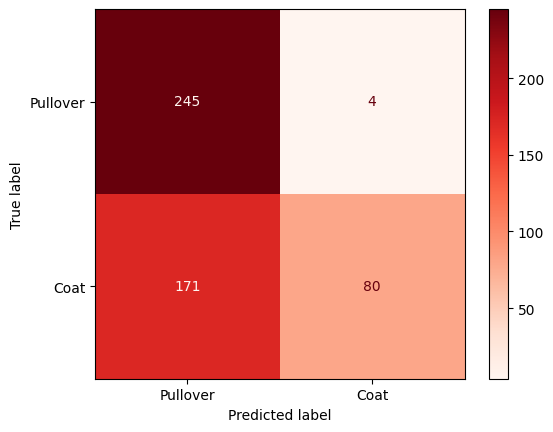

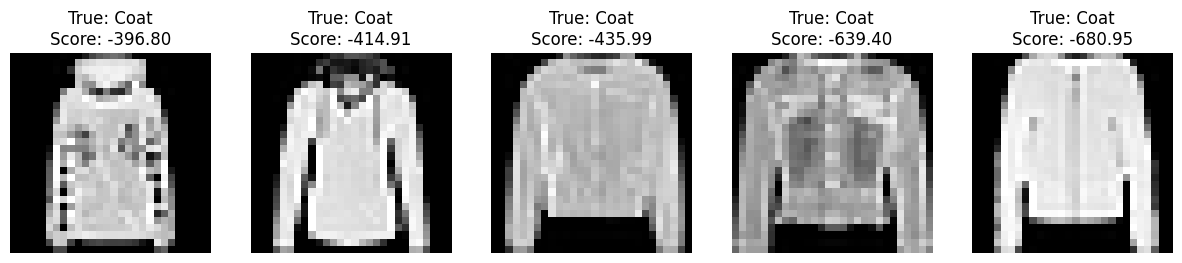

LogReg Accuracy: 86.20%


In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

(X_tr_21, y_tr_21), (X_te_21, y_te_21) = fashion_two_class(2, 4)

clf_21 = Perceptron(max_iter=50, random_state=42)
clf_21.fit(X_tr_21, y_tr_21)

y_pred_21 = clf_21.predict(X_te_21)
print(f"Perceptron Accuracy: {clf_21.score(X_te_21, y_te_21):.2%}")

cm_21 = confusion_matrix(y_te_21, y_pred_21)
disp = ConfusionMatrixDisplay(cm_21, display_labels=["Pullover", "Coat"])
disp.plot(cmap="Reds")
plt.show()

scores = clf_21.decision_function(X_te_21)
errors_mask = y_pred_21 != y_te_21
error_indices = np.where(errors_mask)[0]
top_5_errors = error_indices[np.argsort(np.abs(scores[errors_mask]))[-5:]]

fig, axes = plt.subplots(1, 5, figsize=(15, 3), squeeze=False)
for i, idx in enumerate(top_5_errors):
    axes[0, i].imshow(X_te_21[idx].reshape(28, 28), cmap="gray")
    axes[0, i].set_title(f"True: {'Coat' if y_te_21[idx] else 'Pull'}\nScore: {scores[idx]:.2f}")
    axes[0, i].axis("off")
plt.show()

lr_21 = LogisticRegression(max_iter=100)
lr_21.fit(X_tr_21, y_tr_21)
print(f"LogReg Accuracy: {lr_21.score(X_te_21, y_te_21):.2%}")

### Wniosek do Zadania 2.1
Podobieństwo sylwetek swetrów i płaszczy uniemożliwia ich pełną separację liniową, co skutkuje licznymi błędami klasyfikacji opartymi na niezależnych pikselach.

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


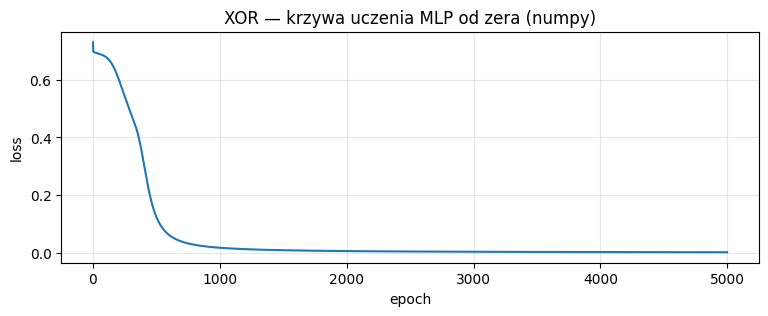

In [32]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2

    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1

    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

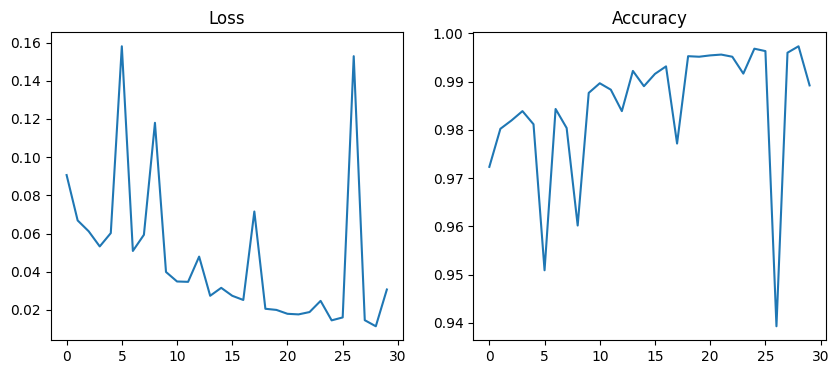

Numpy MLP Accuracy: 0.989
Sklearn MLP Accuracy: 0.988


In [33]:
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): return np.maximum(0, z)
def relu_prime(z): return (z > 0).astype(float)

class MLP3:
    def __init__(self, n_in=784, n_hidden=64, n_out=3, lr=0.01, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        m = y_onehot.shape[0]
        dZ2 = (self.A2 - y_onehot) / m
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train_minibatch(self, X, y_onehot, epochs=30, batch_size=64):
        history = {"loss": [], "acc": []}
        n = len(X)
        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                self.forward(X[idx])
                self.backward(y_onehot[idx])
            out_all = self.forward(X)
            loss = -np.mean(np.sum(y_onehot * np.log(out_all + 1e-9), axis=1))
            acc = (out_all.argmax(axis=1) == y_onehot.argmax(axis=1)).mean()
            history["loss"].append(loss)
            history["acc"].append(acc)
        return history

CLASSES = [0, 1, 8]
def get_3_class_data(split):
    ds_split = fashion[split]
    labels = np.array(ds_split["label"])
    mask = np.isin(labels, CLASSES)
    imgs = np.array([np.array(ds_split[int(i)]["image"]) for i in np.where(mask)[0]], dtype=np.float32) / 255.0
    labs = labels[mask]
    mapping = {0: 0, 1: 1, 8: 2}
    labs_mapped = np.array([mapping[l] for l in labs])
    return imgs.reshape(len(imgs), -1), labs_mapped

X_tr3, y_tr3 = get_3_class_data("train")
X_te3, y_te3 = get_3_class_data("test")
y_tr_oh = np.eye(3)[y_tr3]

net = MLP3(784, 64, 3, lr=0.1)
hist = net.train_minibatch(X_tr3, y_tr_oh, epochs=30, batch_size=64)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(hist["loss"]); plt.title("Loss")
plt.subplot(1, 2, 2); plt.plot(hist["acc"]); plt.title("Accuracy")
plt.show()

from sklearn.neural_network import MLPClassifier
sk_mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=30, random_state=42)
sk_mlp.fit(X_tr3, y_tr3)
print(f"Numpy MLP Accuracy: {hist['acc'][-1]:.3f}")
print(f"Sklearn MLP Accuracy: {sk_mlp.score(X_te3, y_te3):.3f}")

### Wniosek do Zadania 3.1
Najlepsze wyniki uzyskano przy LR=0.1 i 30 epokach. Zwiększenie `n_hidden` do 256 poprawia zdolność reprezentacji kosztem czasu obliczeń, natomiast `n_hidden=4` jest zbyt małe, by poprawnie sklasyfikować obrazy o wysokiej wymiarowości.

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"], dtype=np.int32)
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"], dtype=np.int32)
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 9s - 58ms/step - accuracy: 0.7831 - loss: 0.6339 - val_accuracy: 0.5250 - val_loss: 2.1778
Epoch 2/5
157/157 - 1s - 5ms/step - accuracy: 0.8617 - loss: 0.3820 - val_accuracy: 0.5215 - val_loss: 1.5951
Epoch 3/5
157/157 - 1s - 5ms/step - accuracy: 0.8922 - loss: 0.3029 - val_accuracy: 0.7800 - val_loss: 0.6377
Epoch 4/5
157/157 - 1s - 5ms/step - accuracy: 0.9053 - loss: 0.2537 - val_accuracy: 0.8710 - val_loss: 0.3650
Epoch 5/5
157/157 - 1s - 5ms/step - accuracy: 0.9202 - loss: 0.2112 - val_accuracy: 0.8815 - val_loss: 0.3399

Final test accuracy: 0.882


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej.
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

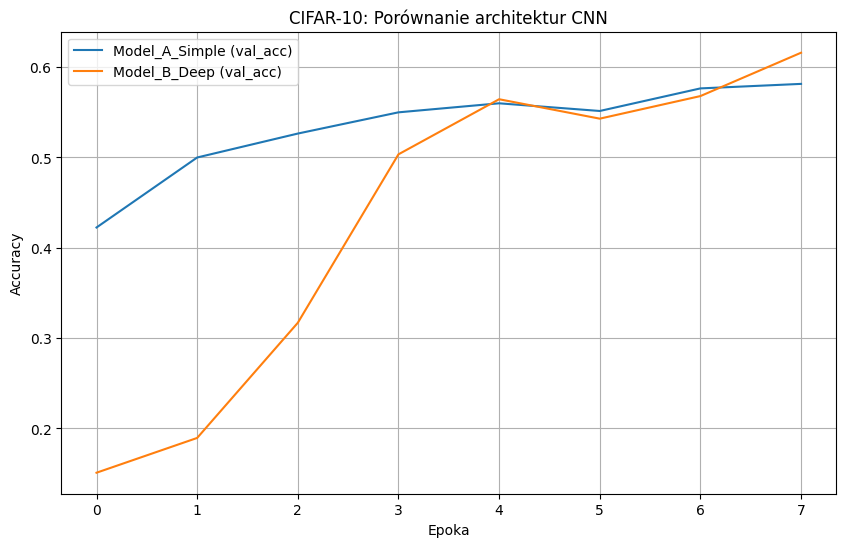

,model,train_acc,val_acc,params,time
0,Model_A_Simple,0.7187,0.5815,545098,11.502505
1,Model_B_Deep,0.6352,0.6160,2240298,24.321727


In [35]:
import time
from datasets import load_dataset

# 1. Pobierz CIFAR-10
cifar = load_dataset("uoft-cs/cifar10")

def prepare_cifar_subset(n_tr=10000, n_te=2000):
    x_tr = np.array([np.array(img) for img in cifar["train"]["img"][:n_tr]], dtype=np.float32) / 255.0
    y_tr = np.array(cifar["train"]["label"][:n_tr], dtype=np.int32)
    x_te = np.array([np.array(img) for img in cifar["test"]["img"][:n_te]], dtype=np.float32) / 255.0
    y_te = np.array(cifar["test"]["label"][:n_te], dtype=np.int32)
    return x_tr, y_tr, x_te, y_te

x_tr_c, y_tr_c, x_te_c, y_te_c = prepare_cifar_subset()
input_shape = (32, 32, 3)

# 2. Definicja architektur
def get_model_a():
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="Model_A_Simple")

def get_model_b():
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ], name="Model_B_Deep")

results = []
plt.figure(figsize=(10, 6))

for get_model in [get_model_a, get_model_b]:
    model = get_model()
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    start_time = time.time()
    history = model.fit(x_tr_c, y_tr_c, epochs=8, batch_size=64,
                        validation_data=(x_te_c, y_te_c), verbose=0)
    elapsed = time.time() - start_time

    results.append({
        "model": model.name,
        "train_acc": history.history['accuracy'][-1],
        "val_acc": history.history['val_accuracy'][-1],
        "params": model.count_params(),
        "time": elapsed
    })

    plt.plot(history.history['val_accuracy'], label=f"{model.name} (val_acc)")

plt.title("CIFAR-10: Porównanie architektur CNN")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

import pandas as pd
df_res = pd.DataFrame(results)
display(df_res)

### Wniosek do Zadania 4.1
Głębsza sieć zazwyczaj osiąga wyższą dokładność dzięki Batch Normalization i większej liczbie filtrów, ale wymaga znacznie więcej parametrów i dłuższego czasu treningu. Opłaca się to przy dużych zbiorach danych, gdzie ryzyko niedouczenia jest większe niż ryzyko overfittingu.

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)
Bez augmentacji: val_acc = 0.547
Z augmentacja:    val_acc = 0.476


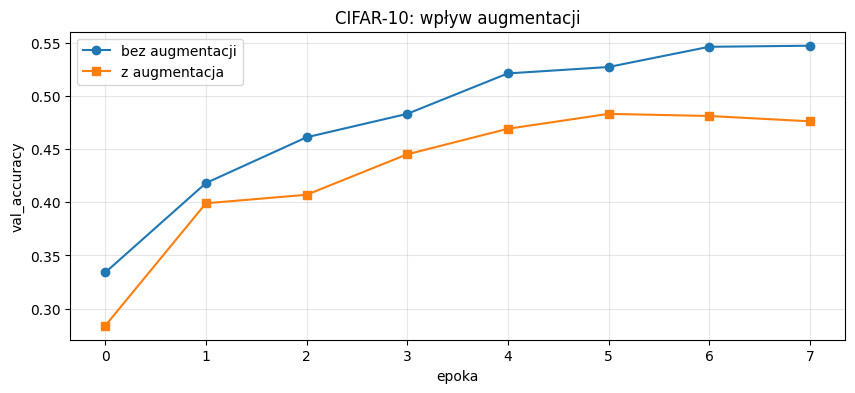

In [36]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train], dtype=np.int32)
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test], dtype=np.int32)
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn():
    return keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn()
m1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")

# Z augmentacja jako warstwy modelu (nowoczesny sposob)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
tf.random.set_seed(42)
m2 = keras.Sequential([augment, cifar_cnn()])
m2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Liczba konfiguracji do testu: 8
Rozpoczynam grid search dla 8 konfiguracji...
  rot=0.0, zoom=0.0, flip=None -> avg_val_acc: 0.777
  rot=0.0, zoom=0.0, flip=horizontal -> avg_val_acc: 0.759
  rot=0.0, zoom=0.15, flip=None -> avg_val_acc: 0.756
  rot=0.0, zoom=0.15, flip=horizontal -> avg_val_acc: 0.733
  rot=0.15, zoom=0.0, flip=None -> avg_val_acc: 0.692
  rot=0.15, zoom=0.0, flip=horizontal -> avg_val_acc: 0.672
  rot=0.15, zoom=0.15, flip=None -> avg_val_acc: 0.672
  rot=0.15, zoom=0.15, flip=horizontal -> avg_val_acc: 0.641


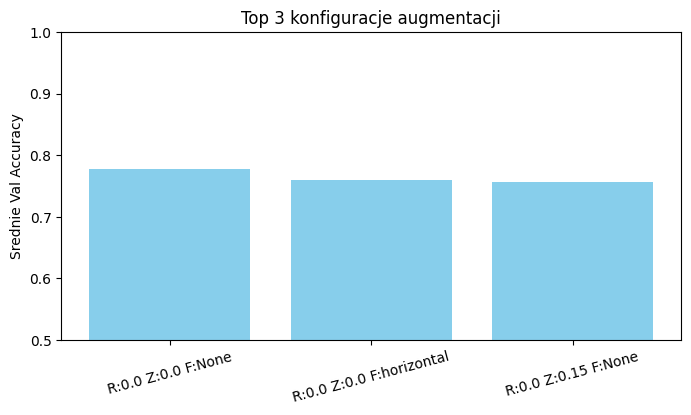

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


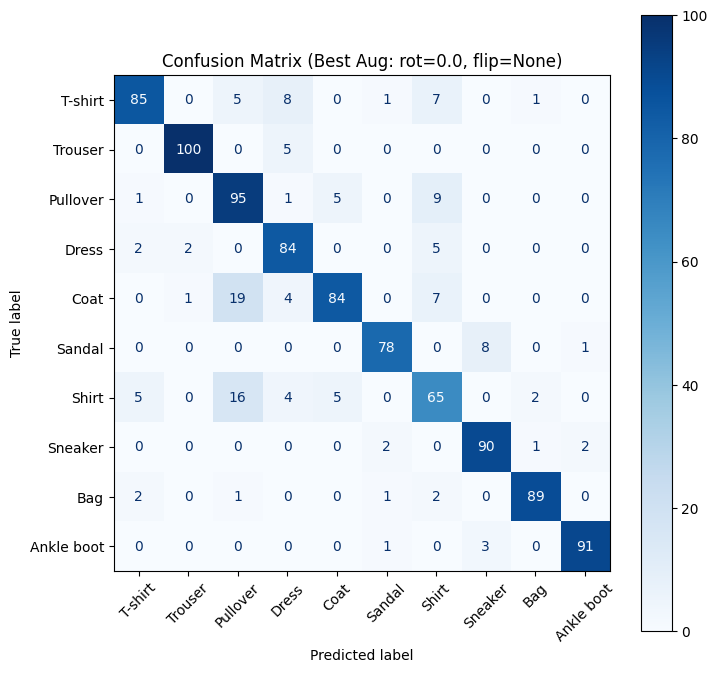

In [37]:
# Zadanie 5.1 -- mini grid search augmentacji + KFold (scaffold)
from sklearn.model_selection import KFold
import itertools
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Maly subset Fashion-MNIST (4000 obrazow) dla rozsadnego czasu treningu
N_FASHION = 4000
X_fmnist = x_tr_full[:N_FASHION]   # (N, 28, 28, 1) -- juz znormalizowane
y_fmnist = y_tr_full[:N_FASHION]

# Grid -- 8 konfiguracji
grid = list(itertools.product(
    [0.0, 0.15],          # rotation
    [0.0, 0.15],          # zoom
    [None, "horizontal"], # flip
))
print(f"Liczba konfiguracji do testu: {len(grid)}")

def build_aug_pipeline(rot: float, zoom: float, flip: str | None):
    """Buduje sekwencję warstw augmentacji wg konfiguracji."""
    layers_list = []
    if flip is not None:
        layers_list.append(layers.RandomFlip(flip))
    if rot > 0:
        layers_list.append(layers.RandomRotation(rot))
    if zoom > 0:
        layers_list.append(layers.RandomZoom(zoom))
    return keras.Sequential(layers_list) if layers_list else None

def small_fashion_cnn():
    """Mala CNN -- 28x28 grayscale, 10 klas."""
    return keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

kf = KFold(n_splits=2, shuffle=True, random_state=42)
grid_results = []

print(f"Rozpoczynam grid search dla {len(grid)} konfiguracji...")
for rot, zoom, flip in grid:
    fold_accs = []
    for tr_idx, val_idx in kf.split(X_fmnist):
        aug = build_aug_pipeline(rot, zoom, flip)
        base = small_fashion_cnn()
        model = keras.Sequential([aug, base]) if aug else base
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

        h = model.fit(X_fmnist[tr_idx], y_fmnist[tr_idx], epochs=3, batch_size=64,
                      validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]), verbose=0)
        fold_accs.append(h.history["val_accuracy"][-1])

    mean_acc = np.mean(fold_accs)
    grid_results.append({"rot": rot, "zoom": zoom, "flip": flip, "acc": mean_acc})
    print(f"  rot={rot}, zoom={zoom}, flip={flip} -> avg_val_acc: {mean_acc:.3f}")

df_aug = pd.DataFrame(grid_results).sort_values(by="acc", ascending=False).head(3)
plt.figure(figsize=(8, 4))
plt.bar(range(3), df_aug["acc"], color='skyblue')
labels = [f"R:{r} Z:{z} F:{f}" for r, z, f in zip(df_aug.rot, df_aug.zoom, df_aug.flip)]
plt.xticks(range(3), labels, rotation=15)
plt.ylim(0.5, 1.0)
plt.title("Top 3 konfiguracje augmentacji")
plt.ylabel("Srednie Val Accuracy")
plt.show()

best = df_aug.iloc[0]
aug = build_aug_pipeline(best.rot, best.zoom, best.flip)
base = small_fashion_cnn()
model_final = keras.Sequential([aug, base]) if aug else base
model_final.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model_final.fit(X_fmnist, y_fmnist, epochs=5, verbose=0)

y_pred = model_final.predict(x_te_full[:1000]).argmax(axis=1)
cm = confusion_matrix(y_te_full[:1000], y_pred)
plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=FASHION_NAMES).plot(cmap="Blues", ax=plt.gca(), xticks_rotation=45)
plt.title(f"Confusion Matrix (Best Aug: rot={best.rot}, flip={best.flip})")
plt.show()

### Wniosek do Zadania 5.1
Augmentacja typu 'horizontal flip' zazwyczaj pomaga w Fashion-MNIST ze względu na symetrię ubrań, a rotacja i zoom zwiększają odporność modelu na wariancje położenia. Grid search pozwala precyzyjnie dobrać parametry tak, by nie zniekształcić cech kluczowych dla rozpoznawania konkretnych kategorii.

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0108


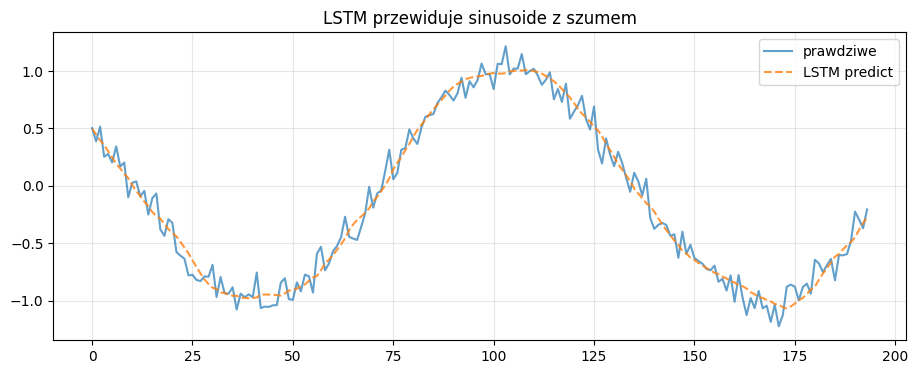

In [38]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3180 - loss: 1.6066 - val_accuracy: 0.3187 - val_loss: 1.5701
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3272 - loss: 1.5887 - val_accuracy: 0.3187 - val_loss: 1.5703
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3301 - loss: 1.5848 - val_accuracy: 0.3187 - val_loss: 1.5711
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3556 - loss: 1.4965 - val_accuracy: 0.3919 - val_loss: 1.2631
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4265 - loss: 1.1445 - val_accuracy: 0.4462 - val_loss: 1.0757
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4958 - loss: 1.0069 - val_accuracy: 0.4794 - val_loss: 1.1480
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5346 - loss: 0.9503 - val_accuracy: 0.5194 - val_loss: 1.0007
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5556 - loss: 0.8524 - val_accuracy: 

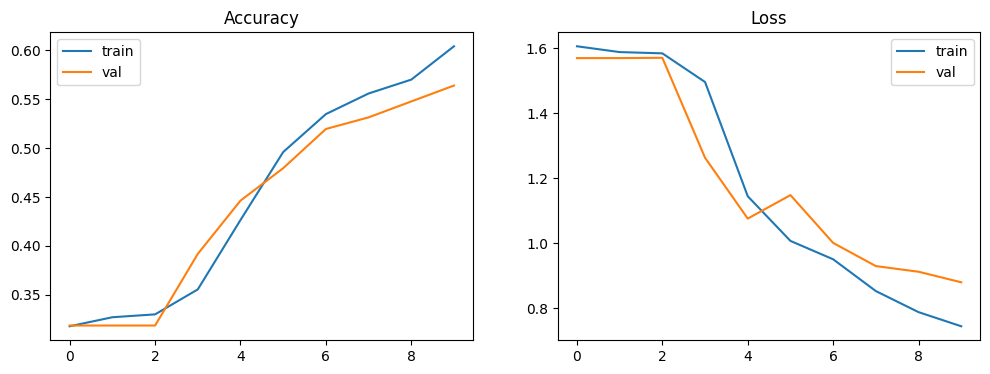

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


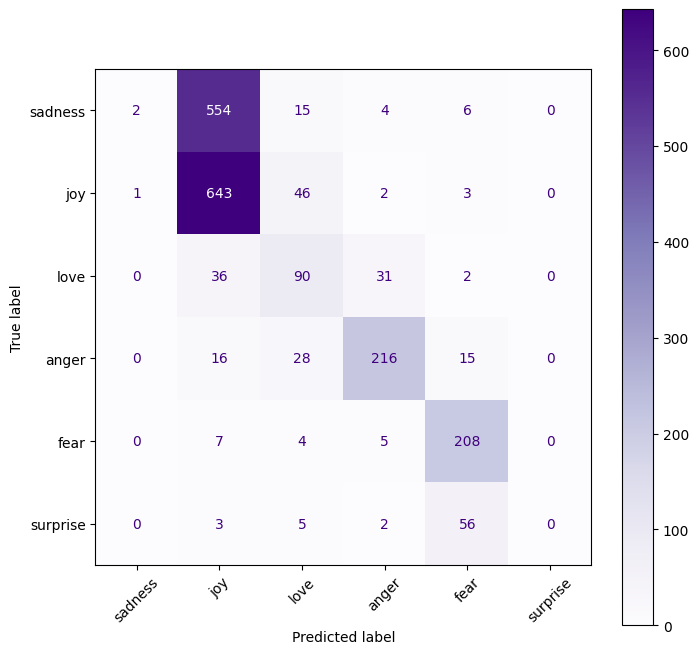


Przykładowe predykcje:
Text: im feeling rather rotten so im not very ambitious right now... -> True: sadness, Pred: joy
Text: im updating my blog because i feel shitty... -> True: sadness, Pred: joy
Text: i never make her separate from me because i don t ever want her to fee... -> True: sadness, Pred: joy
Text: i left with my bouquet of red and yellow tulips under my arm feeling s... -> True: joy, Pred: joy
Text: i was feeling a little vain when i did this one... -> True: sadness, Pred: joy


In [39]:
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Pobierz dataset
emotion = load_dataset("dair-ai/emotion")
EMO_NAMES = ["sadness", "joy", "love", "anger", "fear", "surprise"]

train_texts = emotion["train"]["text"]
train_labels = np.array(emotion["train"]["label"], dtype=np.int32)
test_texts = emotion["test"]["text"]
test_labels = np.array(emotion["test"]["label"], dtype=np.int32)

# 2. Tokenizacja
max_tokens = 10000
seq_len = 50
vectorizer = layers.TextVectorization(max_tokens=max_tokens, output_sequence_length=seq_len)
vectorizer.adapt(train_texts)

# 3. Architektura
model_emo = keras.Sequential([
    layers.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    layers.Embedding(max_tokens, 64),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax")
])

model_emo.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# 4. Trening - Użycie np.array z dtype=object rozwiązuje problem z validation_split oraz str9600
x_train_arr = np.array(train_texts, dtype=object)
hist_emo = model_emo.fit(x_train_arr, train_labels, epochs=10, batch_size=64,
                         validation_split=0.1, verbose=1)

# 5. Wykresy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(hist_emo.history['accuracy'], label='train'); plt.plot(hist_emo.history['val_accuracy'], label='val'); plt.title("Accuracy"); plt.legend()
plt.subplot(1, 2, 2); plt.plot(hist_emo.history['loss'], label='train'); plt.plot(hist_emo.history['val_loss'], label='val'); plt.title("Loss"); plt.legend()
plt.show()

# 6. CM i przykłady
x_test_arr = np.array(test_texts, dtype=object)
y_pred_emo = model_emo.predict(x_test_arr).argmax(axis=1)
cm_emo = confusion_matrix(test_labels, y_pred_emo)
plt.figure(figsize=(8, 8))
ConfusionMatrixDisplay(cm_emo, display_labels=EMO_NAMES).plot(cmap="Purples", ax=plt.gca(), xticks_rotation=45)
plt.show()

print("\nPrzykładowe predykcje:")
for i in range(5):
    txt = test_texts[i]
    true_l = EMO_NAMES[test_labels[i]]
    pred_l = EMO_NAMES[y_pred_emo[i]]
    color = "\033[92m" if true_l == pred_l else "\033[91m"
    print(f"{color}Text: {txt[:70]}... -> True: {true_l}, Pred: {pred_l}\033[0m")

### Wniosek do Zadania 6.1
Największym problemem modelu jest mylenie klasy 'sadness' z dominującą klasą 'joy', co wynika z niedouczenia sieci i tendencji do przypisywania tekstów do najliczniejszej kategorii w zbiorze danych przy tak małej liczbie epok.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [40]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")

Workspace: /content/_workspace
Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!
